In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
from pathlib import Path
from datasets import load_dataset
import gc
from functools import reduce

In [4]:
NAME_TO_CLASS = {
    r"morphine|hydromorphone|dilaudid|fentanyl|oxycodone|tramadol|ketorolac|toradol":
        "Analgesic - Opioid/NSAID",
    r"acetaminophen|tylenol": "Analgesic - Acetaminophen",
    r"ibuprofen|naproxen": "Analgesic - NSAID",
    r"ondansetron|zofran|promethazine|phenergan|metoclopramide|reglan|prochlorperazine":
        "Antiemetic",
    r"vancomycin|ceftriaxone|cefazolin|piperacillin|zosyn|azithromycin|"
    r"ciprofloxacin|metronidazole|flagyl|ampicillin|meropenem|levofloxacin":
        "Antibiotic",
    r"lorazepam|ativan|diazepam|valium|midazolam|versed|alprazolam":
        "Benzodiazepine - Sedative/Anxiolytic",
    r"heparin|enoxaparin|lovenox|warfarin|coumadin|apixaban|rivaroxaban":
        "Anticoagulant",
    r"metoprolol|lopressor|labetalol|atenolol|carvedilol": "Beta Blocker",
    r"lisinopril|enalapril|captopril|ramipril": "ACE Inhibitor",
    r"amlodipine|diltiazem|verapamil|nifedipine": "Calcium Channel Blocker",
    r"nitroglycerin|nitro": "Nitrate",
    r"amiodarone|adenosine|digoxin": "Antiarrhythmic",
    r"furosemide|lasix|bumetanide|torsemide|hydrochlorothiazide": "Diuretic",
    r"methylprednisolone|prednisone|dexamethasone|hydrocortisone": "Corticosteroid",
    r"pantoprazole|omeprazole|famotidine|pepcid|ranitidine": "GI - Acid Suppression",
    r"albuterol|ipratropium|atrovent|levalbuterol": "Bronchodilator",
    r"insulin|dextrose|glucagon": "Insulin/Glucose",
    r"haloperidol|haldol|olanzapine|quetiapine|risperidone": "Antipsychotic",
    r"levetiracetam|keppra|phenytoin|dilantin|valproate|depakote|lacosamide":
        "Anticonvulsant",
    r"normal saline|sodium chloride 0\.9|lactated|ringer|d5w|dextrose 5":
        "IV Fluid",
    r"aspirin|clopidogrel|plavix|ticagrelor": "Antiplatelet",
}
 
def map_name_to_class(name):
    """Map raw medication name to drug class via regex. Returns 'Other' if unmatched."""
    if pd.isna(name):
        return "Unknown"
    name_lower = str(name).lower()
    for pattern, drug_class in NAME_TO_CLASS.items():
        if re.search(pattern, name_lower):
            return drug_class
    return "Other"
 
def safe_col(s):
    """Convert drug class string to a safe pandas column name."""
    return (str(s).lower()
            .replace(" ", "_").replace("-", "_").replace("/", "_")
            .replace("(", "").replace(")", "").replace(",", "")
            .replace("&", "and")[:60])

In [5]:
ETCDESC_TO_CLASS = [
    # Pattern substring (lowercase)         # Shared class label
    ("opioid",                               "Analgesic - Opioid/NSAID"),
    ("analgesic opioid",                     "Analgesic - Opioid/NSAID"),
    ("narcotic",                             "Analgesic - Opioid/NSAID"),
    ("nsaid",                                "Analgesic - NSAID"),
    ("salicylate analgesic",                 "Analgesic - NSAID"),
    ("non-opioid",                           "Analgesic - Acetaminophen"),
    ("acetaminophen",                        "Analgesic - Acetaminophen"),
    ("antiemetic",                           "Antiemetic"),
    ("antibiotic",                           "Antibiotic"),
    ("anti-infective",                       "Antibiotic"),
    ("antimicrobial",                        "Antibiotic"),
    ("benzodiazepine",                       "Benzodiazepine - Sedative/Anxiolytic"),
    ("sedative",                             "Benzodiazepine - Sedative/Anxiolytic"),
    ("anxiolytic",                           "Benzodiazepine - Sedative/Anxiolytic"),
    ("anticoagulant",                        "Anticoagulant"),
    ("thrombin inhibitor",                   "Anticoagulant"),
    ("factor xa",                            "Anticoagulant"),
    ("beta blocker",                         "Beta Blocker"),
    ("beta-adrenergic blocking",             "Beta Blocker"),
    ("ace inhibitor",                        "ACE Inhibitor"),
    ("angiotensin converting enzyme",        "ACE Inhibitor"),
    ("calcium channel blocker",              "Calcium Channel Blocker"),
    ("dihydropyridine",                      "Calcium Channel Blocker"),
    ("nitrate",                              "Nitrate"),
    ("antiarrhythmic",                       "Antiarrhythmic"),
    ("cardiac glycoside",                    "Antiarrhythmic"),
    ("diuretic",                             "Diuretic"),
    ("corticosteroid",                       "Corticosteroid"),
    ("glucocorticoid",                       "Corticosteroid"),
    ("steroid",                              "Corticosteroid"),
    ("proton pump inhibitor",                "GI - Acid Suppression"),
    ("h2-receptor",                          "GI - Acid Suppression"),
    ("acid secretion",                       "GI - Acid Suppression"),
    ("bronchodilator",                       "Bronchodilator"),
    ("beta 2-adrenergic",                    "Bronchodilator"),
    ("anticholinergic bronch",               "Bronchodilator"),
    ("insulin",                              "Insulin/Glucose"),
    ("antidiabetic",                         "Insulin/Glucose"),
    ("sulfonylurea",                         "Insulin/Glucose"),
    ("antipsychotic",                        "Antipsychotic"),
    ("anticonvulsant",                       "Anticonvulsant"),
    ("gaba analog",                          "Anticonvulsant"),
    ("antiepileptic",                        "Anticonvulsant"),
    ("sodium chloride",                      "IV Fluid"),
    ("iv solution",                          "IV Fluid"),
    ("electrolyte replacement",              "IV Fluid"),
    ("antiplatelet",                         "Antiplatelet"),
    ("platelet aggregation inhibitor",       "Antiplatelet"),
    ("salicylate",                           "Antiplatelet"),
    ("statin",                               "Other"),   # chronic, not acute ED action
    ("hmg-coa reductase",                    "Other"),
    ("thyroid",                              "Other"),
    ("vitamin",                              "Other"),
    ("supplement",                           "Other"),
    ("laxative",                             "Other"),
    ("antidepressant",                       "Other"),
]
 
def map_etcdesc_to_class(etcdesc):
    """
    Map an etcdescription string to one of the 22 shared clinical classes.
    Uses the ETCDESC_TO_CLASS list with first-match priority.
    Returns 'Other' for unmatched descriptions.
    """
    if pd.isna(etcdesc):
        return "Other"
    val = str(etcdesc).lower()
    for pattern, cls in ETCDESC_TO_CLASS:
        if pattern in val:
            return cls
    return "Other"
 
# Low-variance threshold
LOW_VARIANCE_THRESHOLD = 0.01

In [7]:
# Registry: logical name -> (hf_config_name, hf_split_name)
DATASETS = {
    "cohort_base": ("cohort_base", "base"),
    "cohort_with_triage": ("cohort_with_triage", "with_triage"),
    "vitals": ("vitals", "vitals"),
    "ed_only_meds": ("ed_only_meds","ed_only"),
    "meds_admitted": ("meds_admitted","meds_admit"),
    "ecg": ("ecg", "ecg"),
    "microbiology_events": ("microbiology_events", "microbiology_events"),
    "labs_base": ("labs_base", "train"),
    "medrecon": ("medrecon", "train"),
    "omr": ("omr", "omr"),
    "radiology_details": ("radiology_details", "radiology_details"),
}

# Date columns to parse per table
DATETIME_COLS = {
    "medrecon": ["charttime"],
    "ed_only_meds": ["charttime"],
    "meds_admitted": ["pyxis_charttime", "emar_charttime", "schedule_time"],
    "cohort_base": ["ed_intime", "ed_outtime"],
}

def mimic_loader(name: str) -> pd.DataFrame:
    """Load a MIMIC-IV derived table from HuggingFace and return as a DataFrame.
 
    Handles the pre_arrival_meds data_dir for medrecon automatically.
    Parses known datetime columns after loading.
    """
    if name not in DATASETS:
        raise ValueError(f"Unknown dataset '{name}'. Valid: {list(DATASETS)}")
    config, split = DATASETS[name]
 
    # Medrecon lives in the pre_arrival_meds subdirectory
    kwargs = dict(verification_mode="no_checks")
    if name == "medrecon":
        kwargs["data_dir"] = "pre_arrival_meds"
 
    print(f"Loading '{name}' from HuggingFace ({'ADS599-Capstone/raw_data'}, config={config}, split={split})...")
    df = load_dataset("ADS599-Capstone/raw_data", config, split=split, **kwargs).to_pandas()
    print(f"  -> {df.shape[0]:,} rows x {df.shape[1]} cols")
 
    # Parse datetime columns
    for col in DATETIME_COLS.get(name, []):
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

    return df

In [8]:
df_recon = mimic_loader("medrecon")
df_ed_meds = mimic_loader("ed_only_meds")
df_admitted = mimic_loader("meds_admitted")
df_cohort = mimic_loader("cohort_base")

recon_raw_rows = len(df_recon)

Loading 'medrecon' from HuggingFace (ADS599-Capstone/raw_data, config=medrecon, split=train)...
  -> 2,869,159 rows x 8 cols
Loading 'ed_only_meds' from HuggingFace (ADS599-Capstone/raw_data, config=ed_only_meds, split=ed_only)...
  -> 337,245 rows x 8 cols
Loading 'meds_admitted' from HuggingFace (ADS599-Capstone/raw_data, config=meds_admitted, split=meds_admit)...
  -> 8,771,619 rows x 12 cols
Loading 'cohort_base' from HuggingFace (ADS599-Capstone/raw_data, config=cohort_base, split=base)...
  -> 399,573 rows x 24 cols


# EDA

In [9]:
# Combine validation and setup
for label, df, expected in [
    ("medrecon", df_recon,
     ["ed_stay_id","subject_id","charttime","name","gsn","ndc","etccode","etcdescription"]),
    ("ed_only_meds", df_ed_meds,
     ["subject_id","stay_id","hadm_id","disposition","charttime","med_rn","medication","in_er"]),
    ("meds_admitted", df_admitted,
     ["subject_id","stay_id","hadm_id","pyxis_charttime","pyxis_med_rn",
      "pyxis_medication","emar_id","emar_charttime","emar_medication",
      "event_txt","scheduletime","in_er"]),
]:
    missing_cols = [c for c in expected if c not in df.columns]
    print(f"\n{label}: shape={df.shape}")
    if missing_cols:
        print(f"  MISSING: {missing_cols}")
    else:
        print(f"  All expected columns present")
 
total_visits = len(df_cohort)
all_stay_ids = df_cohort[["ed_stay_id"]].copy()


medrecon: shape=(2869159, 8)
  All expected columns present

ed_only_meds: shape=(337245, 8)
  All expected columns present

meds_admitted: shape=(8771619, 12)
  All expected columns present


## med_recon EDA

In [10]:
# Missing value
mv = (df_recon.isnull().mean() * 100).round(2)
print(mv[mv > 0] if mv.max() > 0 else "  No missing values")

etccode           0.39
etcdescription    0.39
dtype: float64


In [11]:
# Visit coverage
visits_with_recon = df_recon["ed_stay_id"].nunique()
pct_covered = visits_with_recon / total_visits * 100
print(f"\nVisits with med_recon: {visits_with_recon:,} / {total_visits:,} ({pct_covered:.1f}%)")
print(f"Visits without med_recon: {total_visits - visits_with_recon:,} ({100-pct_covered:.1f}%) -> all-zero state vector")


Visits with med_recon:    296,089 / 399,573 (74.1%)
Visits without med_recon: 103,484 (25.9%) -> all-zero state vector


In [12]:
# Dimensionality
n_names = df_recon["name"].nunique()
n_etccode = df_recon["etccode"].nunique()
n_classes = df_recon["etcdescription"].nunique()
print(f"\nUnique drug names: {n_names:,}")
print(f"Unique ETC codes: {n_etccode:,}")
print(f"Unique drug classes: {n_classes:,} <- chosen encoding ({n_names//n_classes}x reduction)")


Unique drug names:   18,477
Unique ETC codes:    1,195
Unique drug classes: 1,199  <- chosen encoding (15x reduction)


In [13]:
# Build gsn (etcdecription lookup for use in ed_only_meds join)
gsn_lookup = (df_recon[["gsn","etcdescription"]]
              .dropna(subset=["gsn","etcdescription"])
              .drop_duplicates("gsn").reset_index(drop=True))
print(f"\nGSN->class lookup: {len(gsn_lookup):,} unique GSN codes "
      f"(GSN coverage in med_recon: {df_recon['gsn'].notna().mean()*100:.1f}%)")


GSN->class lookup: 9,089 unique GSN codes (GSN coverage in med_recon: 100.0%)


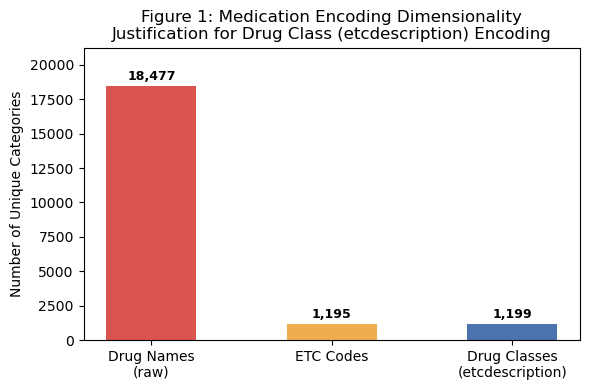

In [14]:
# Dimensionality comparison
fig, ax = plt.subplots(figsize=(6, 4))
cats = ["Drug Names\n(raw)", "ETC Codes", "Drug Classes\n(etcdescription)"]
vals = [n_names, n_etccode, n_classes]
colors = ["#d9534f", "#f0ad4e", "#4C72B0"]
bars = ax.bar(cats, vals, color=colors, width=0.5)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
            f"{val:,}", ha="center", va="bottom", fontweight="bold", fontsize=9)
ax.set_ylabel("Number of Unique Categories")
ax.set_title("Figure 1: Medication Encoding Dimensionality\n"
             "Justification for Drug Class (etcdescription) Encoding")
ax.set_ylim(0, max(vals) * 1.15)
plt.tight_layout()
plt.savefig("fig1_dimensionality_comparison.png", bbox_inches="tight")
plt.show()

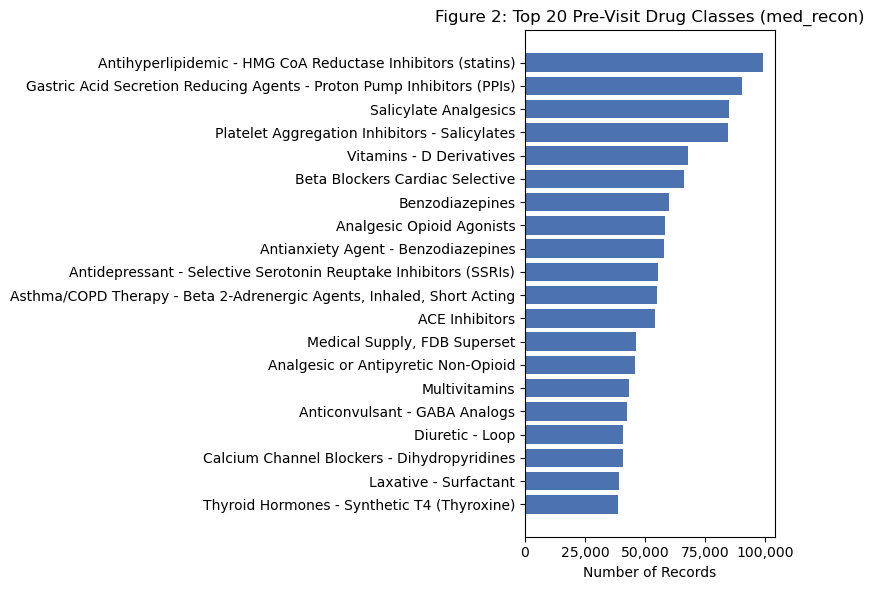

In [15]:
# Top 20 drug classes
top20 = df_recon["etcdescription"].value_counts().head(20).reset_index()
top20.columns = ["drug_class", "count"]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top20["drug_class"][::-1], top20["count"][::-1], color="#4C72B0")
ax.set_xlabel("Number of Records")
ax.set_title("Figure 2: Top 20 Pre-Visit Drug Classes (med_recon)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("fig2_top_drug_classes_recon.png", bbox_inches="tight")
plt.show()


--- Medications per visit ---
count    296089.00
mean          9.69
std           7.74
min           1.00
25%           3.00
50%           8.00
75%          14.00
max          80.00
Name: n_meds, dtype: float64


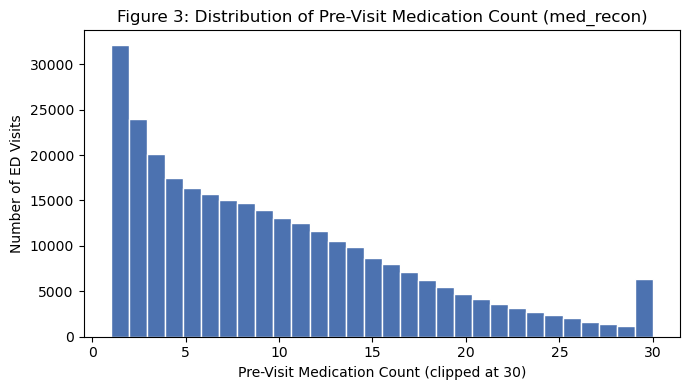

In [16]:
# Meds per visit distribution
meds_per_visit = df_recon.groupby("ed_stay_id")["name"].count().reset_index(name="n_meds")
print("Medications per visit")
print(meds_per_visit["n_meds"].describe().round(2))
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(meds_per_visit["n_meds"].clip(upper=30), bins=30,
        color="#4C72B0", edgecolor="white")
ax.set_xlabel("Pre-Visit Medication Count (clipped at 30)")
ax.set_ylabel("Number of ED Visits")
ax.set_title("Figure 3: Distribution of Pre-Visit Medication Count (med_recon)")
plt.tight_layout()
plt.savefig("fig3_meds_per_visit_recon.png", bbox_inches="tight")
plt.show()

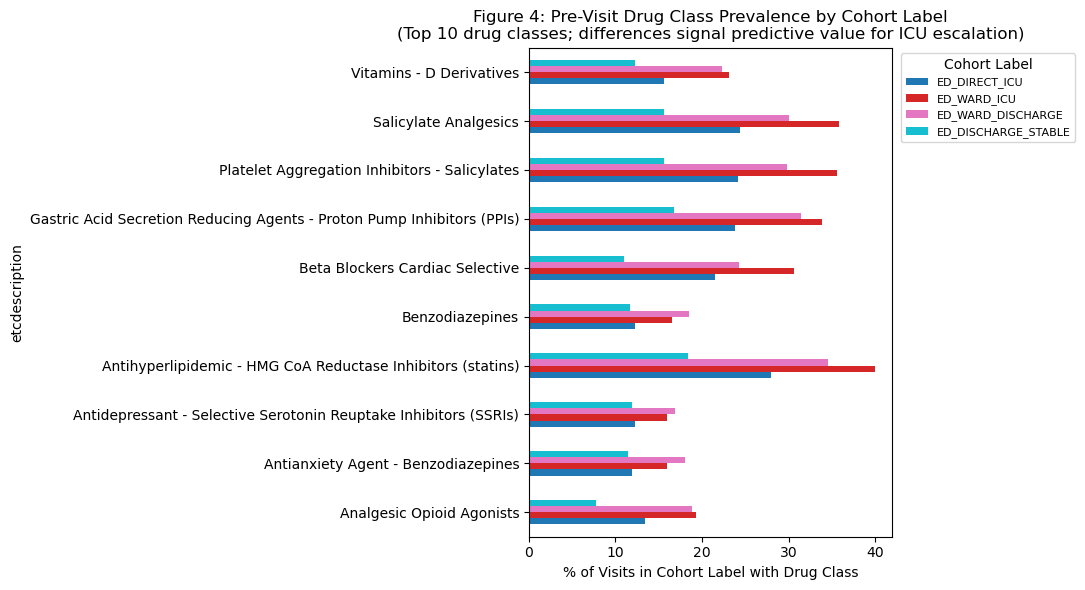

In [17]:
# Drug class prevalence by cohort label
recon_cohort = df_recon.merge(df_cohort[["ed_stay_id","cohort_label"]], on="ed_stay_id", how="left")
top10 = df_recon["etcdescription"].value_counts().head(10).index.tolist()
pivot = (recon_cohort[recon_cohort["etcdescription"].isin(top10)]
         .groupby(["cohort_label", "etcdescription"])["ed_stay_id"].nunique()
         .reset_index(name="visits"))
totals = df_cohort["cohort_label"].value_counts().reset_index()
totals.columns = ["cohort_label", "total"]
pivot = pivot.merge(totals, on="cohort_label")
pivot["pct"] = pivot["visits"] / pivot["total"] * 100
pivot_wide = (pivot.pivot(index="etcdescription", columns="cohort_label", values="pct").fillna(0))
keep = [c for c in ["ED_DIRECT_ICU", "ED_WARD_ICU", "ED_WARD_DISCHARGE", "ED_DISCHARGE_STABLE"]
        if c in pivot_wide.columns]
fig, ax = plt.subplots(figsize=(11, 6))
pivot_wide[keep].plot(kind="barh", ax=ax, colormap="tab10")
ax.set_xlabel("% of Visits in Cohort Label with Drug Class")
ax.set_title("Figure 4: Pre-Visit Drug Class Prevalence by Cohort Label\n"
             "(Top 10 drug classes; differences signal predictive value for ICU escalation)")
ax.legend(title="Cohort Label", bbox_to_anchor=(1.01,1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("fig4_drug_class_by_cohort.png", bbox_inches="tight")
plt.show()

## ed_only_meds EDA

In [18]:
# Missing values
mv_ed = (df_ed_meds.isnull().mean() * 100).round(2)
print(mv_ed[mv_ed > 0] if mv_ed.max() > 0 else "  No missing values")
print("\nNOTE: ed_only_meds has no GSN or etcdescription — drug classes assigned "
      "via name-regex mapping on the 'medication' column.")
print(f"      Also has in_er flag: ED-only records should all be in_er=True.")

# Confirm in_er values
print(f"in_er check (ed_only_meds should be all True)")
print(df_ed_meds["in_er"].value_counts(dropna=False))

hadm_id    100.0
dtype: float64

NOTE: ed_only_meds has no GSN or etcdescription — drug classes assigned via name-regex mapping on the 'medication' column.
      Also has in_er flag: ED-only records should all be in_er=True.

--- in_er check (ed_only_meds should be all True) ---
in_er
True    337245
Name: count, dtype: int64


In [19]:
# Deduplication
raw_rows = len(df_ed_meds)
df_ed_deduped = df_ed_meds.drop_duplicates(subset=["stay_id", "med_rn", "medication", "charttime"])
deduped_rows = len(df_ed_deduped)
dup_pct = (raw_rows - deduped_rows) / raw_rows * 100
print(f"\nRaw rows:             {raw_rows:,}")
print(f"After dedup:          {deduped_rows:,}")
print(f"Duplicates removed:   {raw_rows - deduped_rows:,} ({dup_pct:.1f}%)")


Raw rows:             337,245
After dedup:          337,245
Duplicates removed:   0 (0.0%)


In [20]:
# Assign drug classes via name-regex
df_ed_deduped["etcdescription"] = df_ed_deduped["medication"].apply(map_name_to_class)
n_mapped  = (df_ed_deduped["etcdescription"] != "Unknown").sum()
n_unknown = (df_ed_deduped["etcdescription"] == "Unknown").sum()
print(f"\nClass assigned via name regex: {n_mapped:,} ({n_mapped/deduped_rows*100:.1f}%)")
print(f"Still 'Unknown' (unmatched):   {n_unknown:,} ({n_unknown/deduped_rows*100:.1f}%)")


Class assigned via name regex: 337,245 (100.0%)
Still 'Unknown' (unmatched):   0 (0.0%)


In [21]:
# Coverage
ed_deduped_with_cohort = df_ed_deduped.merge(
    df_cohort[["ed_stay_id", "ed_intime", "ed_outtime", "cohort_label"]],
    left_on="stay_id", right_on="ed_stay_id", how="left"
)
visits_with_edmeds = ed_deduped_with_cohort["ed_stay_id"].nunique()
print(f"\nVisits with ED dispenses: {visits_with_edmeds:,} / {total_visits:,} "
      f"({visits_with_edmeds/total_visits*100:.1f}%)")


Visits with ED dispenses: 128,121 / 399,573 (32.1%)


In [22]:
# Free raw tables
del df_ed_meds, df_ed_deduped
gc.collect()

11112

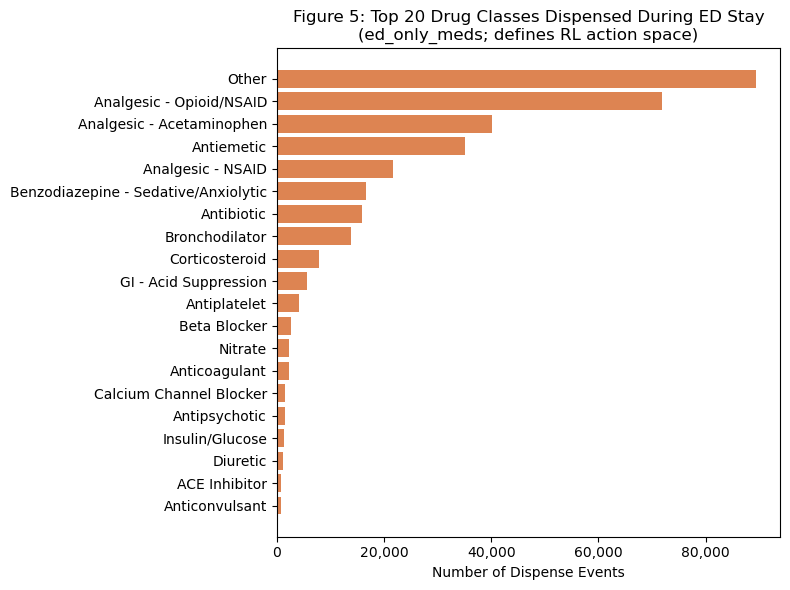

In [23]:
# Top drug classes in ED
top20_ed = ed_deduped_with_cohort["etcdescription"].value_counts().head(20).reset_index()
top20_ed.columns = ["drug_class", "count"]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top20_ed["drug_class"][::-1], top20_ed["count"][::-1], color="#DD8452")
ax.set_xlabel("Number of Dispense Events")
ax.set_title("Figure 5: Top 20 Drug Classes Dispensed During ED Stay\n"
             "(ed_only_meds; defines RL action space)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("fig5_top_drug_classes_ed.png", bbox_inches="tight")
plt.show()


--- Dispenses per visit ---
count    132488.00
mean          2.55
std           1.97
min           1.00
25%           1.00
50%           2.00
75%           3.00
max          64.00
Name: n_dispenses, dtype: float64


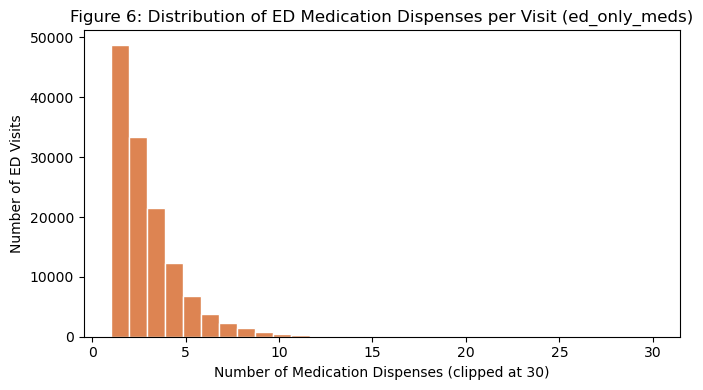

In [24]:
# Dispenses per visit
disp_per_visit = ed_deduped_with_cohort.groupby("stay_id").size().reset_index(name="n_dispenses")
print("\nDispenses per visit")
print(disp_per_visit["n_dispenses"].describe().round(2))
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(disp_per_visit["n_dispenses"].clip(upper=30), bins=30,
        color="#DD8452", edgecolor="white")
ax.set_xlabel("Number of Medication Dispenses (clipped at 30)")
ax.set_ylabel("Number of ED Visits")
ax.set_title("Figure 6: Distribution of ED Medication Dispenses per Visit (ed_only_meds)")
plt.tight_layout()
plt.savefig("fig6_dispenses_per_visit.png", bbox_inches="tight")
plt.show()

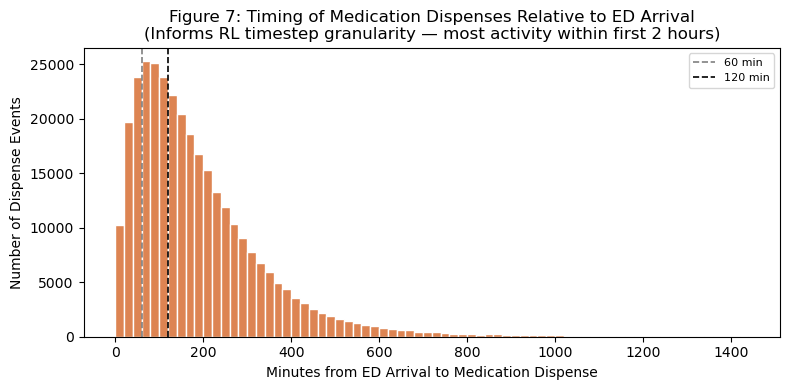

In [25]:
# Timing of dispenses relative to ED arrival
ed_meds_t = ed_deduped_with_cohort.copy()
ed_meds_t["minutes_into_stay"] = (
    (ed_meds_t["charttime"] - ed_meds_t["ed_intime"]).dt.total_seconds() / 60)
ed_meds_t_clean = ed_meds_t[
    (ed_meds_t["minutes_into_stay"] >= 0) &
    (ed_meds_t["minutes_into_stay"] <= 1440)].copy()
 
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ed_meds_t_clean["minutes_into_stay"], bins=72,
        color="#DD8452", edgecolor="white")
ax.axvline(60,  color="gray",  linestyle="--", lw=1.2, label="60 min")
ax.axvline(120, color="black", linestyle="--", lw=1.2, label="120 min")
ax.set_xlabel("Minutes from ED Arrival to Medication Dispense")
ax.set_ylabel("Number of Dispense Events")
ax.set_title("Figure 7: Timing of Medication Dispenses Relative to ED Arrival\n"
             "(Informs RL timestep granularity — most activity within first 2 hours)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("fig7_med_timing.png", bbox_inches="tight")
plt.show()

## med_admitted EDA & Leakage Analysis

In [26]:
# Missing values
mv_adm = (df_admitted.isnull().mean() * 100).round(2)
print(mv_adm[mv_adm > 0])

hadm_id              0.02
pyxis_charttime     88.64
pyxis_med_rn        88.64
pyxis_medication    88.64
emar_id             11.36
emar_charttime      11.36
emar_medication     15.09
event_txt           11.36
scheduletime        11.40
dtype: float64


In [27]:
# in_er flag leakage split
print(df_admitted["in_er"].value_counts(dropna=False))
 
n_iner_true  = df_admitted["in_er"].sum()
n_iner_false = (~df_admitted["in_er"]).sum()
print(f"\n  in_er=True  ({n_iner_true:,}, {n_iner_true/len(df_admitted)*100:.1f}%) "
      f"-> ED action: SAFE to include")
print(f"  in_er=False ({n_iner_false:,}, {n_iner_false/len(df_admitted)*100:.1f}%) "
      f"-> Post-discharge: LEAKAGE, exclude")

in_er
False    7775145
True      996474
Name: count, dtype: int64

  in_er=True  (996,474, 11.4%) -> ED action: SAFE to include
  in_er=False (7,775,145, 88.6%) -> Post-discharge: LEAKAGE, exclude


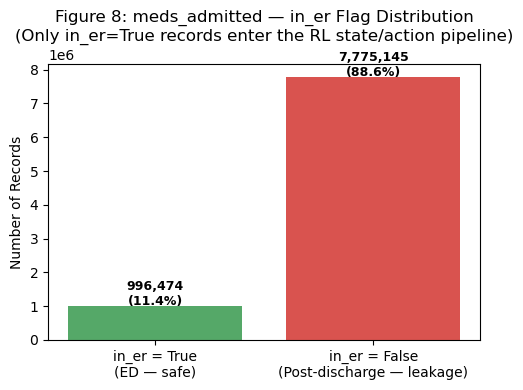

In [28]:
# in_er distribution
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["in_er = True\n(ED — safe)", "in_er = False\n(Post-discharge — leakage)"],
       [n_iner_true, n_iner_false], color=["#55A868","#d9534f"])
for i, val in enumerate([n_iner_true, n_iner_false]):
    ax.text(i, val + len(df_admitted)*0.005,
            f"{val:,}\n({val/len(df_admitted)*100:.1f}%)",
            ha="center", fontsize=9, fontweight="bold")
ax.set_ylabel("Number of Records")
ax.set_title("Figure 8: meds_admitted — in_er Flag Distribution\n"
             "(Only in_er=True records enter the RL state/action pipeline)")
plt.tight_layout()
plt.savefig("fig8_in_er_distribution.png", bbox_inches="tight")
plt.show()

In [29]:
# Pyxis vs EMAR coverage
has_pyxis = df_admitted["pyxis_medication"].notna().sum()
has_emar = df_admitted["emar_medication"].notna().sum()
has_both = (df_admitted["pyxis_medication"].notna() & df_admitted["emar_medication"].notna()).sum()
has_neither = (df_admitted["pyxis_medication"].isna()  & df_admitted["emar_medication"].isna()).sum()
print(f"\nPyxis vs EMAR coverage (all meds_admitted rows)")
print(f"  Pyxis record present: {has_pyxis:,} ({has_pyxis/len(df_admitted)*100:.1f}%)")
print(f"  EMAR record present:  {has_emar:,}  ({has_emar/len(df_admitted)*100:.1f}%)")
print(f"  Both:                 {has_both:,}")
print(f"  Neither:              {has_neither:,}")
print(f"\n  EMAR = administered (gold standard for RL actions).")
print(f"  Pyxis = dispensed (may not have been given — fallback only).")


--- Pyxis vs EMAR coverage (all meds_admitted rows) ---
  Pyxis record present: 996,474 (11.4%)
  EMAR record present:  7,448,107  (84.9%)
  Both:                 0
  Neither:              327,038

  EMAR = administered (gold standard for RL actions).
  Pyxis = dispensed (may not have been given — fallback only).


In [30]:
# event_txt
if "event_txt" in df_admitted.columns:
    print("\ event_txt values (EMAR administration status)")
    print(df_admitted["event_txt"].value_counts(dropna=False).head(15))
    print("\n  Keep only 'Administered' (or equivalent) events for RL action records.")
    print("  Exclude: 'Not Given', 'Refused', 'Held', 'Due'")


--- event_txt values (EMAR administration status) ---
event_txt
Administered                       7307126
None                                996474
Started                             207573
Stopped                             149223
Delayed Administered                 51246
Stopped - Unscheduled                20119
Stopped in Other Location            11555
Administered in Other Location        9768
Restarted                             7689
Stopped As Directed                   4586
Partial Administered                  3071
Rate Change                           2011
Administered Bolus from IV Drip       1178
Name: count, dtype: int64

  Keep only 'Administered' (or equivalent) events for RL action records.
  Exclude: 'Not Given', 'Refused', 'Held', 'Due'


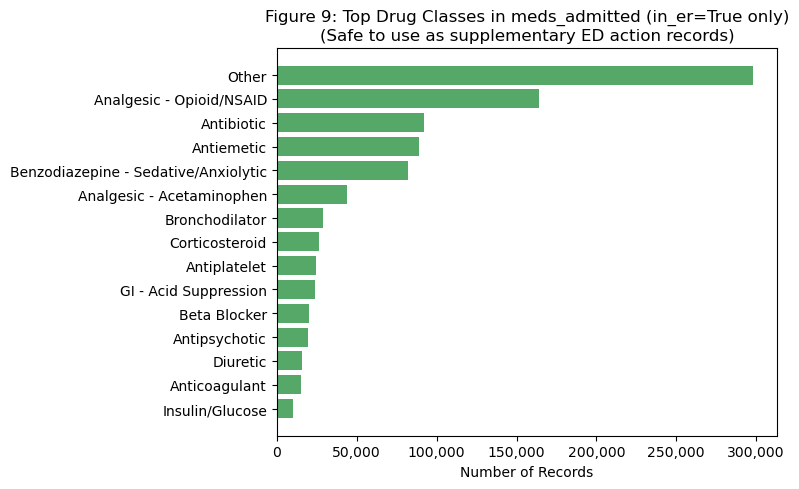

In [31]:
# Top drug classes for in_er=True records
adm_er = df_admitted[df_admitted["in_er"] == True].copy()
adm_er["medication"] = adm_er["emar_medication"].fillna(adm_er["pyxis_medication"])
adm_er["drug_class"] = adm_er["medication"].apply(map_name_to_class)
 
top_adm_er = adm_er["drug_class"].value_counts().head(15).reset_index()
top_adm_er.columns = ["drug_class", "count"]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_adm_er["drug_class"][::-1], top_adm_er["count"][::-1], color="#55A868")
ax.set_xlabel("Number of Records")
ax.set_title("Figure 9: Top Drug Classes in meds_admitted (in_er=True only)\n"
             "(Safe to use as supplementary ED action records)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("fig9_meds_admitted_iner_classes.png", bbox_inches="tight")
plt.show()

# Feature Engineering

In [32]:
# Binary pivot to make more memory efficient
def binary_pivot(df, index_col, class_col, prefix):
    """
    Memory-efficient binary visit x drug-class matrix.
    Strategy: deduplicate to unique (visit, class) pairs FIRST, reducing
    rows dramatically before any pivot operation. Then use unstack on the
    small aggregated series rather than crosstab on the full raw table.
    Finally cast to uint8 (1 byte vs 8 bytes for float64).
    """
    # Collapse to unique (visit, class) pairs
    pairs = (df[[index_col, class_col]]
             .drop_duplicates()
             .assign(flag=1))
 
    # Unstack the small series (not the full raw df)
    ct = (pairs
          .set_index([index_col, class_col])["flag"]
          .unstack(fill_value=0)
          .astype("uint8"))

    ct.columns = [f"{prefix}{safe_col(c)}" for c in ct.columns]
    return ct.reset_index()

# med_recon to static binary drug class vector
df_recon["shared_class"] = df_recon["etcdescription"].apply(map_etcdesc_to_class)
 
print(f"\nShared class distribution (med_recon):")
print(df_recon["shared_class"].value_counts().head(10))
print(f"Records mapped to 'Other': "
      f"{(df_recon['shared_class'] == 'Other').sum():,} "
      f"({(df_recon['shared_class'] == 'Other').mean()*100:.1f}%)")

# Expand ETCDESC_TO_CLASS and reduce the Other bucket over time.
other_mask = df_recon["shared_class"] == "Other"
top_uncovered = (df_recon.loc[other_mask, "etcdescription"]
                 .value_counts()
                 .head(25))
print(f"\nTop 25 etcdescriptions currently mapped to 'Other' (candidates to add to ETCDESC_TO_CLASS):")
print(top_uncovered.to_string())
 
recon_pivot = binary_pivot(df_recon, "ed_stay_id", "shared_class", "recon_")
 
recon_count = (df_recon.groupby("ed_stay_id")["name"]
               .count().reset_index(name="recon_n_total_meds"))
recon_class_count = (df_recon.groupby("ed_stay_id")["shared_class"]
                     .nunique().reset_index(name="recon_n_drug_classes"))


Shared class distribution (med_recon):
shared_class
Other                                   1392119
Benzodiazepine - Sedative/Anxiolytic     155392
Analgesic - Opioid/NSAID                 148704
Analgesic - NSAID                        123919
Corticosteroid                           115008
GI - Acid Suppression                    112938
Insulin/Glucose                          102209
Antiplatelet                             102096
Beta Blocker                              92476
Anticonvulsant                            89350
Name: count, dtype: int64
Records mapped to 'Other': 1,392,119 (48.5%)

Top 25 etcdescriptions currently mapped to 'Other' (candidates to add to ETCDESC_TO_CLASS):
etcdescription
Antihyperlipidemic - HMG CoA Reductase Inhibitors (statins)               99008
Vitamins - D Derivatives                                                  67793
Antidepressant - Selective Serotonin Reuptake Inhibitors (SSRIs)          55517
Medical Supply, FDB Superset                    

In [33]:
# Free df_recon before merging matrix
del df_recon
gc.collect()

28019

In [34]:
# Ruduce to avoid three sequential full-copy allocations
recon_features = reduce(
    lambda l, r: l.merge(r, on="ed_stay_id", how="left"),
    [all_stay_ids, recon_pivot, recon_count, recon_class_count]
)

In [35]:
# Fill nulls column by column to skip any duplicated columns from merge
recon_features = recon_features.loc[:, ~recon_features.columns.duplicated()]
for col in recon_features.columns:
    null_count = recon_features[col].isna().sum()
    if null_count > 0:
        recon_features[col] = recon_features[col].fillna(0)

In [36]:
# Downcast all binary flag columns to uint8 (1 byte vs 8 bytes for float64)
for col in recon_features.columns:
    if col.startswith("recon_") and col not in ("recon_n_total_meds","recon_n_drug_classes"):
        recon_features[col] = recon_features[col].astype("uint8")
recon_features["recon_n_total_meds"] = recon_features["recon_n_total_meds"].astype("uint16")
recon_features["recon_n_drug_classes"] = recon_features["recon_n_drug_classes"].astype("uint8")

In [37]:
# Drop low-variance columns
flag_cols = [c for c in recon_features.columns
             if c.startswith("recon_") and c not in ("recon_n_total_meds","recon_n_drug_classes")]
visit_prevalence = recon_features[flag_cols].mean()
low_var_cols = visit_prevalence[visit_prevalence < LOW_VARIANCE_THRESHOLD].index.tolist()

# Also drop recon_other (48.5% of records map here, almost every patient with any meds gets a 1)
if "recon_other" in recon_features.columns:
    low_var_cols.append("recon_other")
 
if low_var_cols:
    recon_features = recon_features.drop(columns=low_var_cols)
    print(f"Dropped {len(low_var_cols)} recon columns "
          f"(low-variance or uninformative): {low_var_cols}")

Dropped 3 recon columns (low-variance or uninformative): ['recon_analgesic___acetaminophen', 'recon_iv_fluid', 'recon_other']


In [38]:
# Free intermediate objects before next pivot
del recon_pivot, recon_count, recon_class_count
gc.collect()

0

In [39]:
print(f"med_recon feature matrix: {recon_features.shape}")
print(f"  RAM usage: {recon_features.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"  Visits with all-zero (no pre-visit meds): "
      f"{(recon_features.iloc[:,1:].sum(axis=1)==0).sum():,}")
recon_features.to_csv("features_med_recon_static.csv", index=False)
print("Saved: features_med_recon_static.csv")

med_recon feature matrix: (399573, 22)
  RAM usage: 12.0 MB
  Visits with all-zero (no pre-visit meds): 103,484
Saved: features_med_recon_static.csv


In [40]:
# ed_only_meds -> cumulative binary + timestep action records
ed_pivot = binary_pivot(ed_deduped_with_cohort, "ed_stay_id", "etcdescription", "edmeds_")
 
ed_count = (ed_deduped_with_cohort.groupby("ed_stay_id")
            .size().reset_index(name="edmeds_n_dispenses"))
ed_class_count = (ed_deduped_with_cohort.groupby("ed_stay_id")["etcdescription"]
                  .nunique().reset_index(name="edmeds_n_drug_classes"))
 
ed_meds_features = reduce(
    lambda l, r: l.merge(r, on="ed_stay_id", how="left"),
    [all_stay_ids, ed_pivot, ed_count, ed_class_count]
)
 
ed_meds_features = ed_meds_features.loc[:, ~ed_meds_features.columns.duplicated()]
for col in ed_meds_features.columns:
    null_count = ed_meds_features[col].isna().sum()
    if null_count > 0:
        ed_meds_features[col] = ed_meds_features[col].fillna(0)
 
for col in ed_meds_features.columns:
    if col.startswith("edmeds_") and col not in ("edmeds_n_dispenses", "edmeds_n_drug_classes"):
        ed_meds_features[col] = ed_meds_features[col].astype("uint8")
ed_meds_features["edmeds_n_dispenses"] = ed_meds_features["edmeds_n_dispenses"].astype("uint16")
ed_meds_features["edmeds_n_drug_classes"] = ed_meds_features["edmeds_n_drug_classes"].astype("uint8")

In [41]:
# Free intermediate objects for next pivot
del ed_pivot, ed_count, ed_class_count
gc.collect()

0

In [42]:
# Timestep action records for RL trajectory construction
class_vocab = sorted(ed_deduped_with_cohort["etcdescription"].dropna().unique().tolist())
class_to_idx = {c: i for i, c in enumerate(class_vocab)}
 
ed_meds_timestep = (ed_meds_t_clean[
    ["ed_stay_id", "charttime", "minutes_into_stay", "etcdescription", "cohort_label"]
].dropna(subset=["minutes_into_stay"]).copy())
ed_meds_timestep["action_idx"] = (ed_meds_timestep["etcdescription"]
                                   .map(class_to_idx).fillna(-1).astype(int))
print(f"\ned_only_meds timestep records: {ed_meds_timestep.shape}")
print(f"RL action space size: {len(class_vocab)} drug classes")
ed_meds_timestep.to_csv("features_ed_meds_timestep_actions.csv", index=False)
pd.DataFrame({"action_idx": list(class_to_idx.values()),
              "drug_class": list(class_to_idx.keys())
              }).to_csv("action_vocab.csv", index=False)
print("Saved: features_ed_meds_timestep_actions.csv, action_vocab.csv")


ed_only_meds timestep records: (323190, 6)
RL action space size: 22 drug classes
Saved: features_ed_meds_timestep_actions.csv, action_vocab.csv


In [43]:
# meds_admitted in_er=True -> supplementary EMAR action records
adm_er_clean = adm_er.copy()
if "event_txt" in adm_er_clean.columns:
    # Include rows where:
    #   (a) event_txt is null — these are Pyxis-only dispenses with no EMAR
    #       status; all in_er=True rows fall here; treated as valid ED actions
    #   (b) event_txt contains a confirmed administration keyword
    # Explicitly exclude only known non-administration statuses.
    non_admin_mask = adm_er_clean["event_txt"].str.lower().str.contains(
        "not given|refused|held|due|stopped|restarted|rate change",
        na=False  # na=False means null event_txt is NOT excluded
    )
    n_before = len(adm_er_clean)
    adm_er_clean = adm_er_clean[~non_admin_mask]
    print(f"Before event_txt filter: {n_before:,} -> after: {len(adm_er_clean):,}")
    print(f"  (null event_txt Pyxis rows retained as valid ED actions)")
 
# Use EMAR charttime, fall back to Pyxis charttime, then scheduletime
adm_er_clean["action_time"] = (adm_er_clean["emar_charttime"]
                               .fillna(adm_er_clean["pyxis_charttime"])
                               .fillna(adm_er_clean.get("scheduletime")))
 
# Strip timezone from action_time
if adm_er_clean["action_time"].dt.tz is not None:
    adm_er_clean["action_time"] = adm_er_clean["action_time"].dt.tz_localize(None)

# Join via stay_id = ed_stay_id to get ed_intime
adm_er_clean = adm_er_clean.merge(
    df_cohort[["ed_stay_id", "ed_intime"]],
    left_on="stay_id", right_on="ed_stay_id", how="left"
)

# Strip timezone from ed_intime after merge
if adm_er_clean["ed_intime"].dt.tz is not None:
    adm_er_clean["ed_intime"] = adm_er_clean["ed_intime"].dt.tz_localize(None)
adm_er_clean["minutes_into_stay"] = (
    (adm_er_clean["action_time"] - adm_er_clean["ed_intime"]).dt.total_seconds() / 60)
adm_er_clean = adm_er_clean[
    (adm_er_clean["minutes_into_stay"] >= 0) &
    (adm_er_clean["minutes_into_stay"] <= 1440)].copy()
adm_er_clean["action_idx"] = (adm_er_clean["drug_class"]
                              .map(class_to_idx).fillna(-1).astype(int))
 
print(f"Final meds_admitted ED action records: {len(adm_er_clean):,}")

# Confirm no row explosion from the stay_id join
assert len(adm_er_clean) <= len(adm_er), \
    f"Row count increased after join: {len(adm_er_clean)} > {len(adm_er)} — check for duplicate stay_ids"
 
adm_er_clean[[
    "ed_stay_id", "action_time", "minutes_into_stay",
    "medication", "drug_class", "action_idx"
]].to_csv("features_meds_admitted_er_actions.csv", index=False)
print("Saved: features_meds_admitted_er_actions.csv")
print("NOTE: in_er=False records excluded (post-discharge leakage)")
 

Before event_txt filter: 996,474 -> after: 996,474
  (null event_txt Pyxis rows retained as valid ED actions)
Final meds_admitted ED action records: 912,419
Saved: features_meds_admitted_er_actions.csv
NOTE: in_er=False records excluded (post-discharge leakage)


In [44]:
# Combined static feature matrix
med_only = all_stay_ids.copy()
med_only = med_only.merge(recon_features, on="ed_stay_id", how="left")
med_only = med_only.merge(ed_meds_features, on="ed_stay_id", how="left")

# Final fill visits with no meds get 0 for all flags
med_only = med_only.fillna(0)

# Downcast float columns that crept back in after merge
for col in med_only.columns:
    if col == "ed_stay_id":
        continue
    if med_only[col].dtype == "float64":
        if med_only[col].max() <= 1:
            med_only[col] = med_only[col].astype("uint8")
        elif med_only[col].max() <= 65535:
            med_only[col] = med_only[col].astype("uint16")
 
assert len(med_only) == len(df_cohort), "Row count mismatch — every cohort visit must have a row"
assert med_only["ed_stay_id"].nunique() == len(med_only), "Duplicate ed_stay_id rows detected"
assert med_only.isnull().sum().sum() == 0, "Unexpected nulls in final output"
 
n_recon_cols = sum(1 for c in med_only.columns if c.startswith("recon_"))
n_edmeds_cols = sum(1 for c in med_only.columns if c.startswith("edmeds_"))
print(f"Medication feature matrix (merge-ready): {med_only.shape}")
print(f"  ed_stay_id: 1 column (join key)")
print(f"  recon_*:    {n_recon_cols} columns (static pre-visit drug class flags)")
print(f"  edmeds_*:   {n_edmeds_cols} columns (cumulative ED dispense flags)")
print(f"  Total medication features: {n_recon_cols + n_edmeds_cols}")
print(f"  Missing values: None")
print(f"  RAM: {med_only.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\nJoin key: ed_stay_id")
print(f"Merge instruction: cohort.merge(med_features, on='ed_stay_id', how='left')")

med_only.to_csv("combined_medication_features.csv", index=False)
print("Saved: combined_medication_features.csv")

Medication feature matrix (merge-ready): (399573, 46)
  ed_stay_id: 1 column (join key)
  recon_*:    21 columns (static pre-visit drug class flags)
  edmeds_*:   24 columns (cumulative ED dispense flags)
  Total medication features: 45
  Missing values: None
  RAM: 22.0 MB

Join key: ed_stay_id
Merge instruction: cohort.merge(med_features, on='ed_stay_id', how='left')
Saved: combined_medication_features.csv


In [45]:
# Standardise timestep action file columns for trajectory builder
ed_meds_timestep["source"] = "ed_only_meds"
ed_meds_timestep = ed_meds_timestep[[
    "ed_stay_id", "charttime", "minutes_into_stay",
    "etcdescription", "action_idx", "source"
]].rename(columns={"etcdescription": "drug_class"})
ed_meds_timestep.to_csv("features_ed_meds_timestep_actions.csv", index=False)

# Standardise meds_admitted action file to same schema
adm_actions_out = adm_er_clean[[
    "ed_stay_id", "action_time", "minutes_into_stay",
    "drug_class", "action_idx"
]].copy()
adm_actions_out["source"] = "meds_admitted"
adm_actions_out = adm_actions_out.rename(columns={"action_time": "charttime"})
adm_actions_out = adm_actions_out[[
    "ed_stay_id", "charttime", "minutes_into_stay",
    "drug_class", "action_idx", "source"
]]
adm_actions_out.to_csv("features_meds_admitted_er_actions.csv", index=False)

# Combined action file — all medication actions across both tables, sorted by visit and time
all_med_actions = pd.concat([ed_meds_timestep, adm_actions_out], ignore_index=True)
all_med_actions = all_med_actions.sort_values(["ed_stay_id", "minutes_into_stay"]).reset_index(drop=True)
all_med_actions.to_csv("features_all_med_actions.csv", index=False)
 
print(f"\nAction files:")
print(f"  features_ed_meds_timestep_actions.csv:  {len(ed_meds_timestep):,} rows")
print(f"  features_meds_admitted_er_actions.csv:  {len(adm_actions_out):,} rows")
print(f"  features_all_med_actions.csv:           {len(all_med_actions):,} rows (combined)")
print(f"\nAll action files schema: ed_stay_id | charttime | minutes_into_stay | drug_class | action_idx | source")

pd.DataFrame({
    "action_idx": list(class_to_idx.values()),
    "drug_class":  list(class_to_idx.keys())
}).to_csv("action_vocab.csv", index=False)
print("Saved: action_vocab.csv")


Action files:
  features_ed_meds_timestep_actions.csv:  323,190 rows
  features_meds_admitted_er_actions.csv:  912,419 rows
  features_all_med_actions.csv:           1,235,609 rows (combined)

All action files schema: ed_stay_id | charttime | minutes_into_stay | drug_class | action_idx | source
Saved: action_vocab.csv
